In [234]:
import cv2
import numpy as np
from google.colab.patches import cv2_imshow
from google.colab import files
import io
from PIL import Image
from dataclasses import dataclass
import math





In [235]:
@dataclass
class info_casualties:
    age: int
    eme: int
    priority_score: int
    x: float
    y: float
    z: float = 0.0


In [236]:
@dataclass
class info_camp:
    capacity: int
    x: float
    y: float
    z: float = 0.0


In [237]:
list_contour_data_casualties = []
list_contour_data_camp = []
image_results = []


In [238]:
def convert_data(shape,color,x,y):
  shape_val = 0
  color_val = 0
  if shape == "Star":
    shape_val = 3
  elif shape == "Triangle":
    shape_val = 2
  elif shape == "Square":
    shape_val = 1

  if color == "Red":
    color_val = 3
  elif color == "Yello":
    color_val = 2
  elif color == "Green":
    color_val = 1

  priority_score = shape_val * color_val
  # print(priority_score , shape, color)

  if shape != "Circle":
    list_contour_data_casualties.append(info_casualties(shape_val,color_val,priority_score,x,y))
  else:
    if color == "Gray":
      list_contour_data_camp.append(info_camp(2,x,y))
    elif color == "Pink":
      list_contour_data_camp.append(info_camp(3,x,y))
    elif color == "Blue":
      list_contour_data_camp.append(info_camp(4,x,y))






In [239]:
def detect_bg(img):
  hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)

  lower_blue = np.array([90, 50, 50])
  upper_blue = np.array([140, 255, 255])
  ocean_mask = cv2.inRange(hsv, lower_blue, upper_blue)

  lower_land = np.array([25, 40, 40])
  upper_land = np.array([90, 255, 255])
  land_mask = cv2.inRange(hsv, lower_land, upper_land)

  kernel = np.ones((5,5), np.uint8)
  ocean_mask = cv2.morphologyEx(ocean_mask, cv2.MORPH_CLOSE, kernel)
  land_mask = cv2.morphologyEx(land_mask, cv2.MORPH_CLOSE, kernel)

  output = img.copy() # Use img here as well
  output[ocean_mask > 0] = (255, 0, 0)   # color ocean blue
  output[land_mask > 0] = (0, 255, 0)    # color land green

  cv2_imshow(output)

  return output

In [240]:
def get_color_name(hsv_color):
    h, s, v = hsv_color

    if v < 40: return "Black"
    if s < 30 and v > 200: return "Gray"

    if h < 10 or h > 170: return "Red"
    elif 10 <= h < 25: return "Yello"
    #elif 25 <= h < 35: return "Yellow"
    elif 35 <= h < 85: return "Green"
    elif 85 <= h < 130: return "Blue"
    elif 130 <= h < 170: return "Pink"

    return "Unknown"

In [241]:
def detect_shape(contour, peri, area):
    approx = cv2.approxPolyDP(contour, 0.03 * peri, True)
    vertices = len(approx)

    circularity = 4 * np.pi * area / (peri * peri) if peri > 0 else 0

    hull = cv2.convexHull(contour)
    hull_area = cv2.contourArea(hull)
    solidity = area / hull_area if hull_area > 0 else 0

    if circularity > 0.85:
        return "Circle"

    if vertices == 3:
        return "Triangle"

    elif vertices == 4:
        x, y, w, h = cv2.boundingRect(approx)
        aspect_ratio = w / float(h)
        return "Square" if 0.90 <= aspect_ratio <= 1.10 else "Rectangle"

    elif vertices == 5:
        return "Pentagon"

    else:
        if solidity < 0.75:
            return "Star"
        else:
            return "Polygon"

In [242]:
def process_image(image_array=None):
    if image_array is None:
        print("Error: Could not load image")
        return

    output = image_array.copy()

    gray = cv2.cvtColor(image_array, cv2.COLOR_BGR2GRAY)
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    _, thresh = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

    contours, _ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    hsv = cv2.cvtColor(image_array, cv2.COLOR_BGR2HSV)
    # print(f"Detected {len(contours)} potential shapes...")

    valid_shapes = 0

    for contour in contours:
        area = cv2.contourArea(contour)
        peri = cv2.arcLength(contour, True)

        valid_shapes += 1

        shape = detect_shape(contour, peri, area)

        M = cv2.moments(contour)
        if M["m00"] != 0:
            cX = int(M["m10"] / M["m00"])
            cY = int(M["m01"] / M["m00"])
        else:
            continue

        mask = np.zeros(gray.shape, np.uint8)
        cv2.circle(mask, (cX, cY), 5, 255, -1)
        mean_color = cv2.mean(hsv, mask=mask)
        color_name = get_color_name(mean_color[:3])


        convert_data(shape,color_name,cX,cY)



        cv2.drawContours(output, [contour], -1, (0, 0, 255), 2)
        cv2.circle(output, (cX, cY), 4, (255, 255, 255), -1)

        label = f"{color_name} {shape}"
        font = cv2.FONT_HERSHEY_SIMPLEX
        font_scale = 0.5
        thickness = 2

        (text_width, text_height), _ = cv2.getTextSize(label, font, font_scale, thickness)
        text_x = cX - (text_width // 2)
        text_y = cY - (text_height // 2) - 10

        cv2.rectangle(output, (text_x - 5, text_y - 15), (text_x + text_width + 5, text_y + 5), (0,0,0), -1)
        cv2.putText(output, label, (text_x, text_y), font, font_scale, (255, 255, 255), 1)

        #print(f"Shape: {label} (Area: {int(area)})")

    print("\nProcessed Image:")
    return output

In [243]:
def compute_priority_and_ratio(segregated_output):


    blue_list, pink_list, grey_list = segregated_output

    def camp_priority(camp_list):
        total = 0
        for age, eme in camp_list:
            total += age * eme
        return total

    blue_priority = camp_priority(blue_list)
    pink_priority = camp_priority(pink_list)
    grey_priority = camp_priority(grey_list)

    camp_priority_list = [blue_priority, pink_priority, grey_priority]

    total_priority = blue_priority + pink_priority + grey_priority
    total_casualties = len(blue_list) + len(pink_list) + len(grey_list)

    if total_casualties == 0:
        priority_ratio = 0
    else:
        priority_ratio = total_priority / total_casualties
    return camp_priority_list, priority_ratio


In [244]:
def segregate_casualties(casualties_list, camp_list):

    blue_list = []
    pink_list = []
    grey_list = []


    for camp in camp_list:
        if camp.capacity == 4:
            blue_camp = (camp.x, camp.y)
        elif camp.capacity == 3:
            pink_camp = (camp.x, camp.y)
        elif camp.capacity == 2:
            grey_camp = (camp.x, camp.y)


    casualties_sorted = sorted(
        casualties_list,
        key=lambda c: (c.priority_score, c.eme),
        reverse=True
    )


    for casualty in casualties_sorted:

        cx, cy = casualty.x, casualty.y

        distances = [
            ("blue", math.dist((cx, cy), blue_camp)),
            ("pink", math.dist((cx, cy), pink_camp)),
            ("grey", math.dist((cx, cy), grey_camp))
        ]

        distances.sort(key=lambda x: x[1])

        for camp_name, _ in distances:

            if camp_name == "blue" and len(blue_list) < 4:
                blue_list.append([casualty.age, casualty.eme])
                break

            elif camp_name == "pink" and len(pink_list) < 3:
                pink_list.append([casualty.age, casualty.eme])
                break

            elif camp_name == "grey" and len(grey_list) < 2:
                grey_list.append([casualty.age, casualty.eme])
                break


    return [blue_list, pink_list, grey_list]



[Option 1] Upload an image file:


Saving 1.png to 1 (15).png
Saving 2.png to 2 (9).png
Saving 3.png to 3 (7).png
Saving 4.png to 4 (8).png
Saving 5.png to 5 (6).png
Saving 6.png to 6 (6).png
Saving 7.png to 7 (5).png
Saving 8.png to 8 (6).png
Saving 9.png to 9 (6).png
Saving 10.png to 10 (6).png

Processing: 1 (15).png

Processed Image:


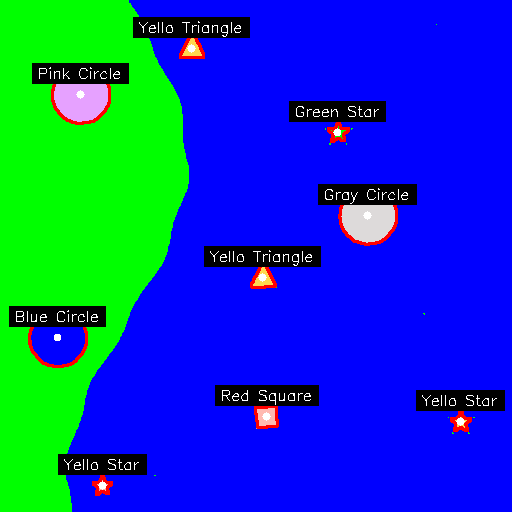

Casualties availabe at each camp: [[[3, 2], [1, 3]], [[2, 2], [3, 1]], [[3, 2], [2, 2]]]
Camp Priority List: [9, 7, 10]
Priority Ratio: 4.333333333333333

Processing: 2 (9).png

Processed Image:


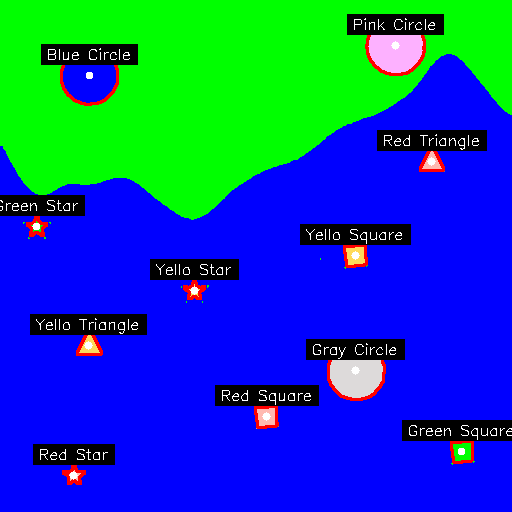

Casualties availabe at each camp: [[[3, 2], [2, 2], [2, 2], [2, 2]], [[2, 3], [3, 2], [1, 3]], [[3, 3], [3, 2]]]
Camp Priority List: [18, 15, 15]
Priority Ratio: 5.333333333333333

Processing: 3 (7).png

Processed Image:


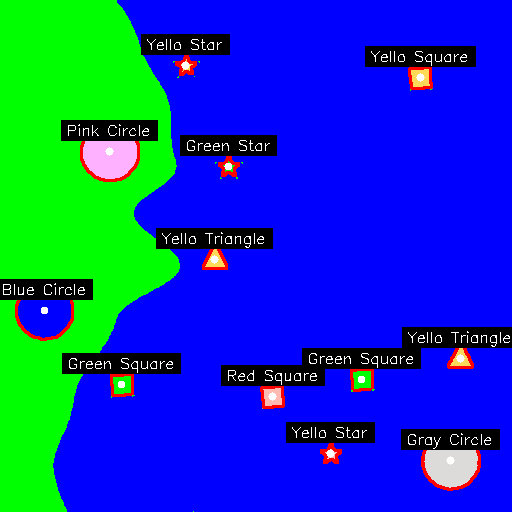

Casualties availabe at each camp: [[[3, 3], [3, 2], [3, 2], [3, 2]], [[3, 2], [2, 2], [2, 2]], [[2, 3], [3, 2]]]
Camp Priority List: [27, 14, 12]
Priority Ratio: 5.888888888888889

Processing: 4 (8).png

Processed Image:


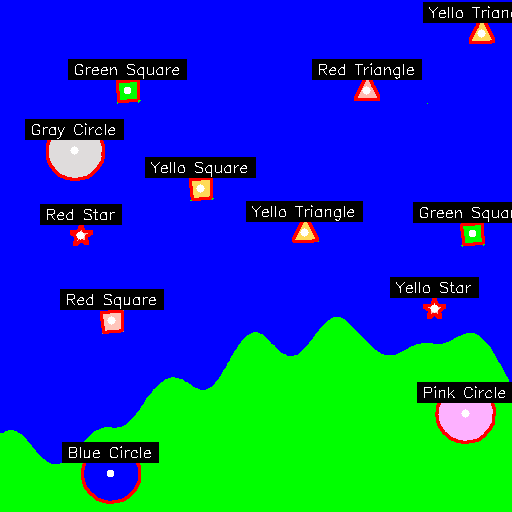

Casualties availabe at each camp: [[[3, 3], [3, 2], [3, 2], [3, 2]], [[2, 3], [3, 2], [3, 2]], [[3, 3], [2, 3]]]
Camp Priority List: [27, 18, 15]
Priority Ratio: 6.666666666666667

Processing: 5 (6).png

Processed Image:


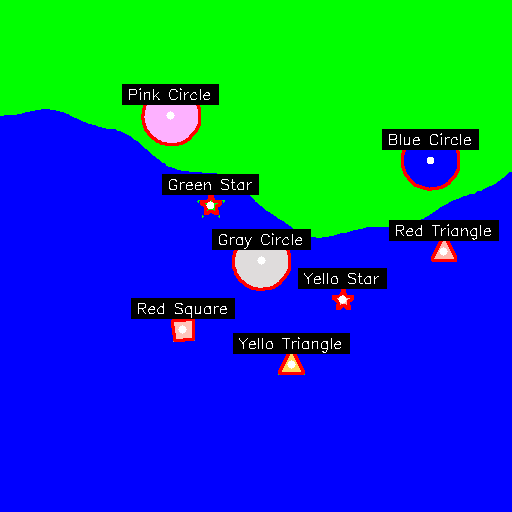

Casualties availabe at each camp: [[[2, 3], [2, 3], [2, 3], [3, 2]], [[3, 3], [3, 2], [3, 2]], [[3, 3], [3, 2]]]
Camp Priority List: [24, 21, 15]
Priority Ratio: 6.666666666666667

Processing: 6 (6).png

Processed Image:


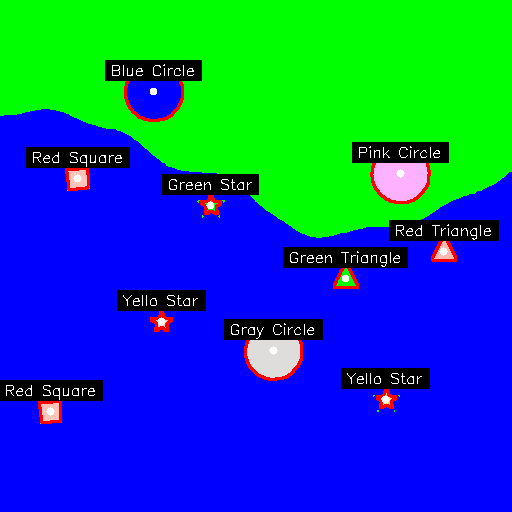

Casualties availabe at each camp: [[[3, 3], [3, 2], [3, 2], [3, 2]], [[2, 3], [2, 3], [2, 3]], [[3, 3], [2, 3]]]
Camp Priority List: [27, 18, 15]
Priority Ratio: 6.666666666666667

Processing: 7 (5).png

Processed Image:


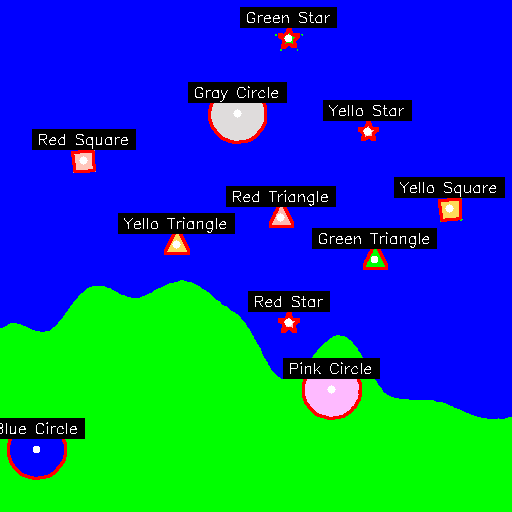

Casualties availabe at each camp: [[[3, 3], [2, 3], [2, 3], [3, 2]], [[3, 3], [2, 3], [2, 3]], [[3, 3], [2, 3]]]
Camp Priority List: [27, 21, 15]
Priority Ratio: 7.0

Processing: 8 (6).png

Processed Image:


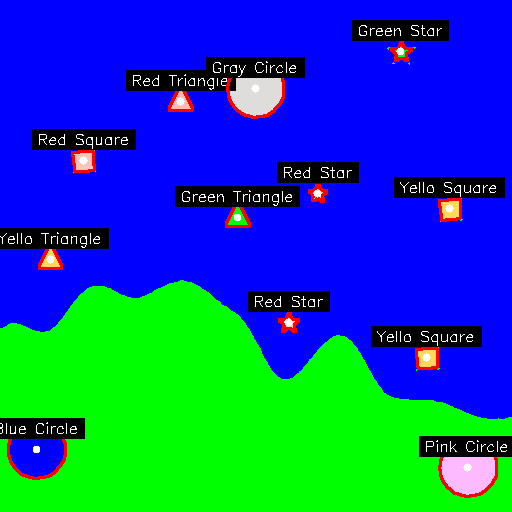

Casualties availabe at each camp: [[[3, 3], [3, 3], [2, 3], [2, 3]], [[3, 3], [3, 3], [2, 3]], [[3, 3], [2, 3]]]
Camp Priority List: [30, 24, 15]
Priority Ratio: 7.666666666666667

Processing: 9 (6).png

Processed Image:


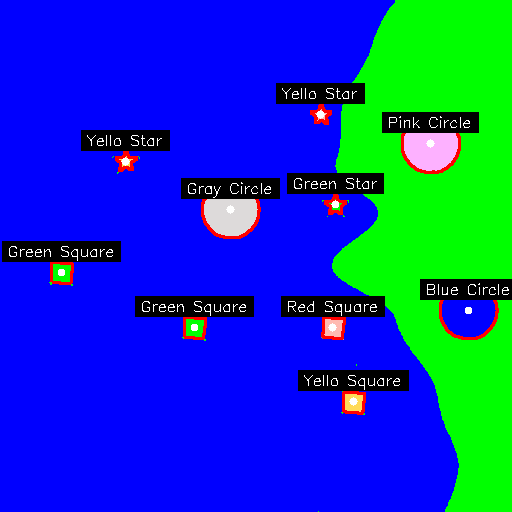

Casualties availabe at each camp: [[[3, 3], [3, 3], [2, 3], [2, 3]], [[3, 3], [2, 3], [2, 3]], [[3, 3], [3, 3]]]
Camp Priority List: [30, 21, 18]
Priority Ratio: 7.666666666666667

Processing: 10 (6).png

Processed Image:


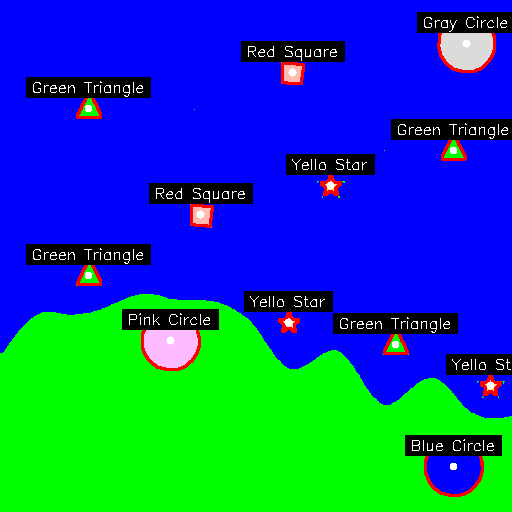

Casualties availabe at each camp: [[[3, 3], [2, 3], [2, 3], [2, 3]], [[3, 3], [3, 3], [3, 3]], [[3, 3], [2, 3]]]
Camp Priority List: [27, 27, 15]
Priority Ratio: 7.666666666666667
Images sorted by rescue ratio: ['8 (6).png', '9 (6).png', '10 (6).png', '7 (5).png', '4 (8).png', '5 (6).png', '6 (6).png', '3 (7).png', '2 (9).png', '1 (15).png']


In [245]:
print("\n[Option 1] Upload an image file:")
uploaded = files.upload()

if uploaded:

    for filename in uploaded.keys():
        print(f"\nProcessing: {filename}")
        image_bytes = uploaded[filename]
        image = Image.open(io.BytesIO(image_bytes))
        image_array = cv2.cvtColor(np.array(image.convert('RGB')), cv2.COLOR_RGB2BGR)
        image_array = process_image(image_array=image_array)
        detect_bg(image_array)

        seg_casu = segregate_casualties(list_contour_data_casualties, list_contour_data_camp)
        camp_priority_list, priority_ratio = compute_priority_and_ratio(seg_casu)
        print(f"Casualties availabe at each camp: {seg_casu}")
        print(f"Camp Priority List: {camp_priority_list}")
        print(f"Priority Ratio: {priority_ratio}")

        image_results.append((filename, priority_ratio))

image_results.sort(key=lambda x: x[1], reverse=True)
sorted_image_names = [img[0] for img in image_results]
print("Images sorted by rescue ratio:", sorted_image_names)





